# Unified inference + plotting (SoilN and Tube FT)

This notebook now uses shared utility modules:
- `utils/inference_helpers.py`
- `utils/plotting_helpers.py`

Behavior:
- `plot_scope="single"`: plot one resolved scenario.
- `plot_scope="all"`: plot **all unique treatments** for the selected `year` + `farm`.


In [1]:
from pathlib import Path

ROOT = Path.cwd()
print('Working dir:', ROOT)


Working dir: c:\Users\spothapragada\Documents\Projects\Txr-DSSAT\finetunning\finetunning - Copy


In [2]:
from utils.plotting_helpers import plot_scenarios
from utils.inference_helpers import evaluate_nmrse_table
from utils.eval_metrics_helpers import run_eval_for_farm_ids


c:\Users\spothapragada\Documents\Projects\Txr-DSSAT\finetunning\finetunning - Copy\utils\inference_helpers.py:172: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint =

Padding....
Creating Tensors....


c:\Users\spothapragada\Miniconda3\envs\repo_env\Lib\site-packages\torch\nn\modules\transformer.py:720: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  return torch._transformer_encoder_layer_fwd(


Padding....
Creating Tensors....
Padding....
Creating Tensors....
Padding....
Creating Tensors....
Padding....
Creating Tensors....
Padding....
Creating Tensors....
Padding....
Creating Tensors....
Padding....
Creating Tensors....


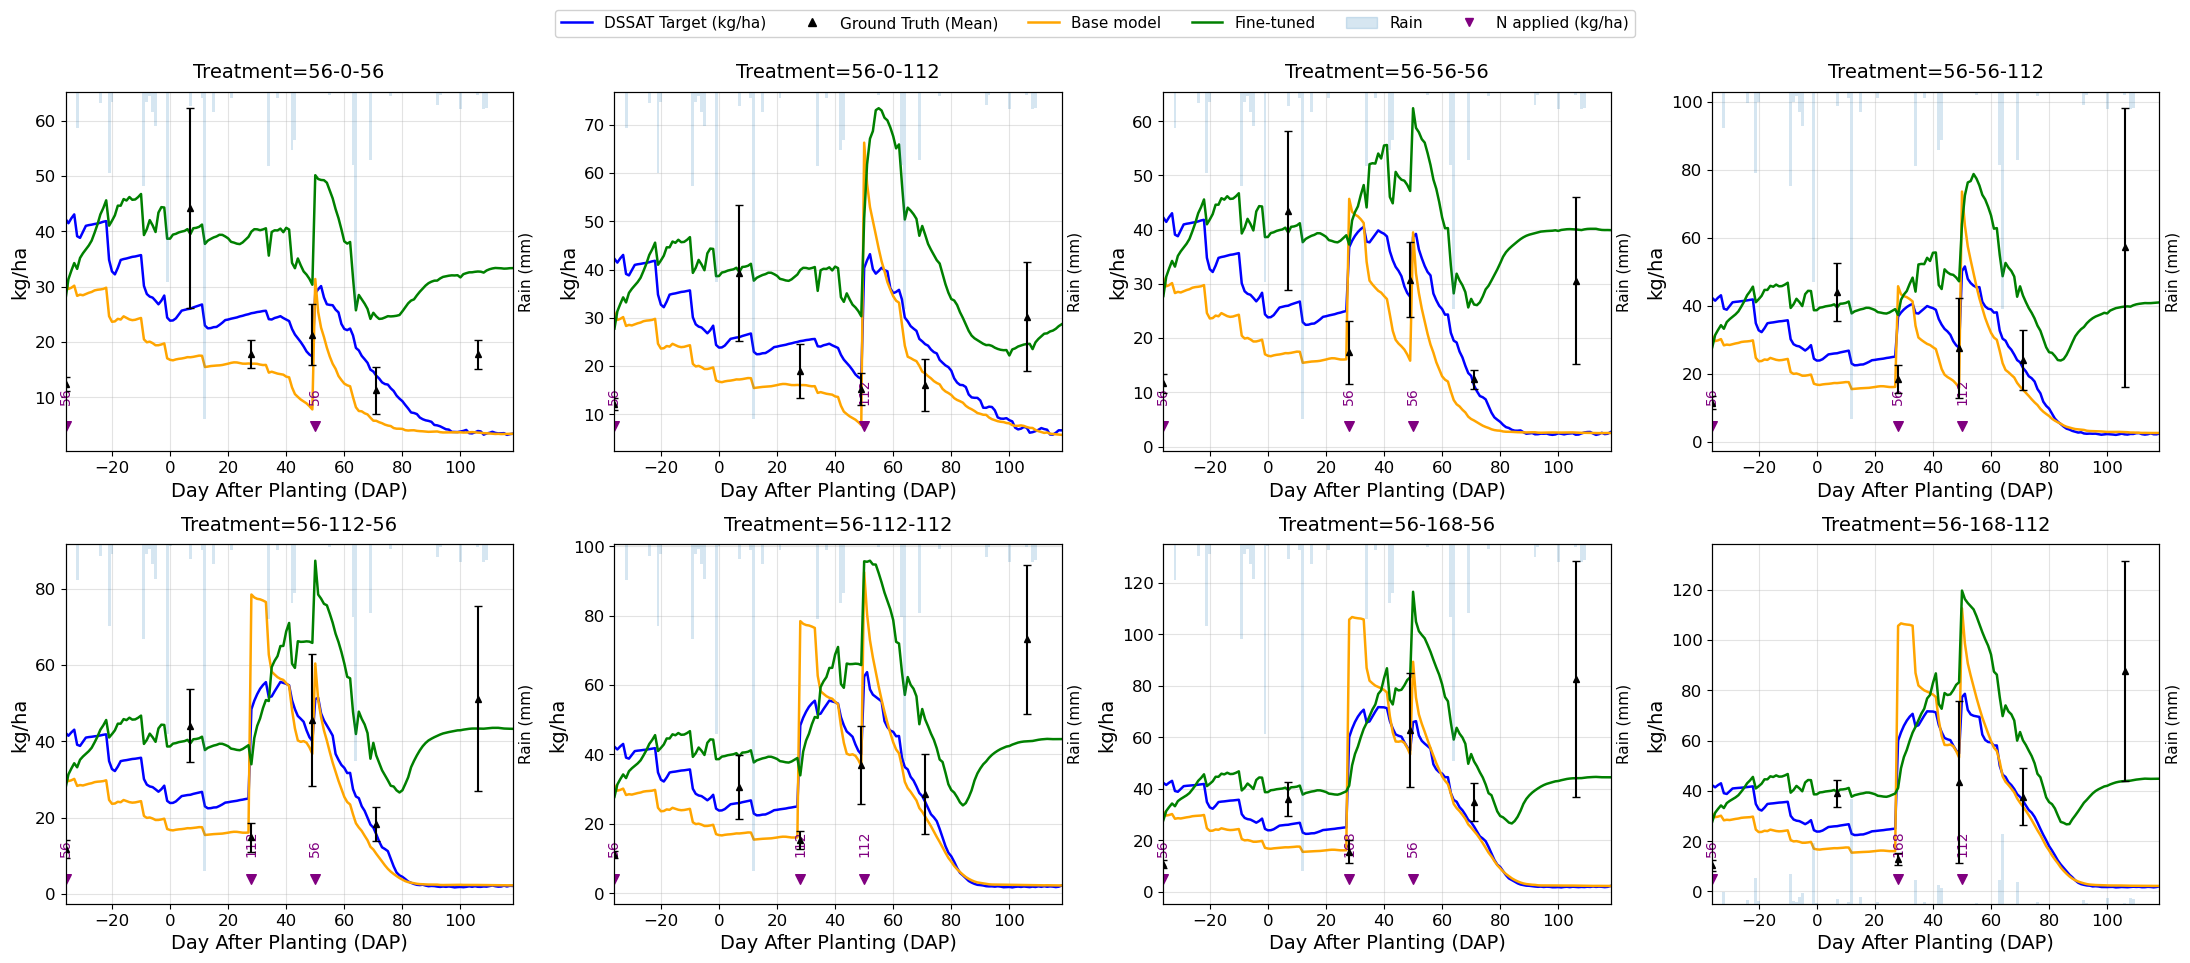

In [4]:
# Plot all 8 SoilN treatments for a given scenario
_ = plot_scenarios(
    mode="soiln",
    year=2011,           # Change this to any year you want to check
    farm="AS",           # Change to AS, JR, or PP
    plot_scope="all",
    # treatment='56-56-56',    # 'all' will plot the 2x4 grid for all treatments
    show_dssat=True,     # Shows the continuous blue line
    show_ft=True,        # Shows the green fine-tuned line
    show_gt=True,
     # Shows the triangles with mean/error bars
)


c:\Users\spothapragada\Documents\Projects\Txr-DSSAT\finetunning\finetunning - Copy\utils\inference_helpers.py:204: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base_ckpt = 

Padding....
Creating Tensors....
Padding....
Creating Tensors....
Padding....
Creating Tensors....
Padding....
Creating Tensors....
Padding....
Creating Tensors....
Padding....
Creating Tensors....
Padding....
Creating Tensors....
Padding....
Creating Tensors....


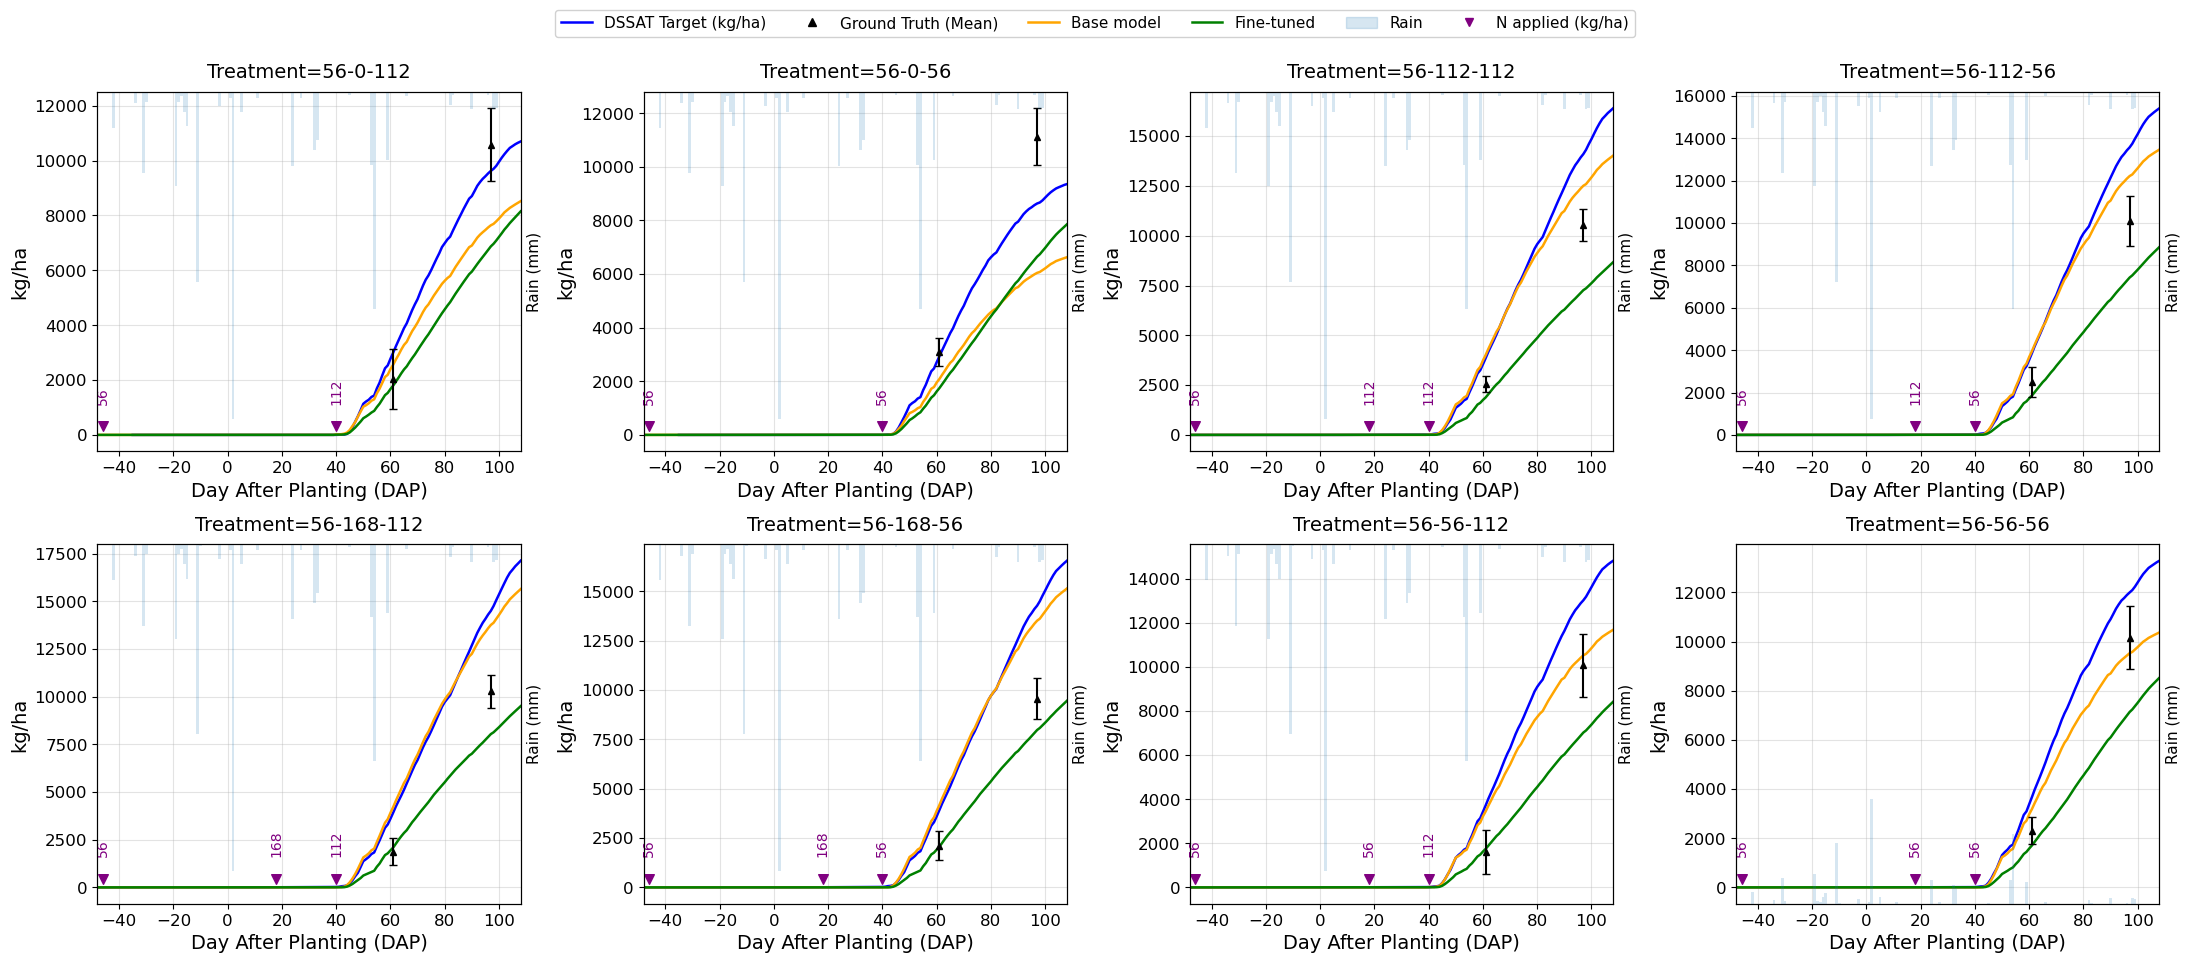

In [5]:
_ = plot_scenarios(
    mode="tube",
    year=2011,           # Change this to any year you want to check
    farm="AS",           # Change to AS, JR, or PP
    plot_scope="all",
    # treatment='56-56-56',    # 'all' will plot the 2x4 grid for all treatments
    show_dssat=True,     # Shows the continuous blue line
    show_ft=True,        # Shows the green fine-tuned line
    show_gt=True,
     # Shows the triangles with mean/error bars
)

In [ ]:
soiln_summary = run_eval_for_farm_ids(
    farm_ids=["JR2011", "AS2012", "AS2014"],
    data_df=new_data,          # your SoilN dataframe
    ppsr=ppsr,
    model_base=model_base,
    model_ft=fine_tuned_model,
    global_range=GLOBAL_RANGE,
    mode="soiln",
)
 


In [ ]:
# To evaluate against EXACT Ground Truth Points:
df_exact = evaluate_nmrse_table(mode="soiln", year=2011, farm="AS", use_mean_gt=False)
display(df_exact)

# To evaluate against the MEAN of the Upper and Lower Bounds:
df_bounds = evaluate_nmrse_table(mode="soiln", year=2011, farm="AS", use_mean_gt=True)
display(df_bounds)


In [ ]:
# Global Average Evaluation (use_mean_gt=True for bound mean)
df_global = evaluate_nmrse_table(mode="soiln", use_mean_gt=False)
display(df_global)
